In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import torch
import numpy as np
import matplotlib.pyplot as plt

import kind
import ex_duffing
import util_nn
import reinforcement_learning as rl

In [2]:
# --! define a reward function --!

state_ndim = 2
action_ndim = 1

state_cost = 1.0 * np.eye(state_ndim)
action_cost = 1.0 * np.eye(action_ndim)

setpoint = [1.0, 0.0]

reward_id = ex_duffing.duffing_reward(state_cost, action_cost, setpoint, beta=1.0, lambda_E=0.05)
reward_ood = ex_duffing.duffing_reward(state_cost, action_cost, setpoint, beta=20.0, lambda_E=0.1)

In [3]:
duffing_exc = ex_duffing.duffing_adapter(ex_duffing.make_duffing('ood', reward_ood))
duffing_nom = ex_duffing.duffing_adapter(ex_duffing.make_duffing('id', reward_id))

In [4]:
# --! make a base policy --!

class policy_base:
    """Defines a PyTorch-based base policy."""

    def __init__(self, gain, setpoint):
        self.gain = torch.from_numpy(gain).to(torch.float32)
        self.setpoint = torch.atleast_2d(torch.tensor(setpoint))

    def __call__(self, obs):
        obs = obs - self.setpoint
        return -torch.matmul(obs, torch.transpose(self.gain, 0, 1))

# --! LQR should be the same for both oscillators, so assume that it makes no difference
# --! which plant to use, nominal or excursion
policy_gain = ex_duffing.make_policy(duffing_nom.env, q=state_cost, r=action_cost)
policy_lqr = policy_base(policy_gain, setpoint)

In [5]:
residual_used = False

if residual_used:
    parser = kind.create_args_parser()
    args = parser.parse_args(
        args=[
            '--file_dir', '../../data/dreamer',
            '--file_name', 'duffing',
            '--data_nsample', '3848',
            '--feature_ndim', '4',
            '--target_ndim', '2',
            '--data_train_size', '0.6',

            '--lookback_nsample', '384',
            '--forecast_nsample', '192',

            '--batch_size', '64',
            '--nepoch', '50',
            '--patience', '10',
            '--checkpoints', '../../models/dreamer',

            '--seg_nsample_stat', '192',
            '--seg_nsample_trans', '192',
            '--fun_stat', '{"sin": 4, "cos": 4}',
            '--fun_trans', '{"data": 12}',
        ]
    )

    setpoint = [1.0, 0.0]

    # --! create a dataset
    dataset = ex_duffing.dataset(
        args.file_dir, args.file_name, args.file_ext,
        args.data_nsample,
        (args.data_train_size, args.data_test_size),
        args.batch_size,
        (args.lookback_nsample, args.forecast_nsample), setpoint, load_normalized=False) # <-- dataset is not normalized

    residual_policy = rl.policy(dataset.normalizer)
    policy_path = args.checkpoints + '/' + 'policy_checkpoint.pth'
    residual_policy.load_state_dict(torch.load(policy_path, weights_only=True))
    util_nn.freeze_module(residual_policy.net)
    residual_policy.eval()
    zeta_nom = torch.tensor(0.0017)
    zeta_exc = torch.tensor(0.44)
else:
    residual_policy = None
    zeta_nom = 0.0
    zeta_exc = 0.0

In [6]:
duffing_exc.base_policy = policy_lqr
duffing_exc.residual_policy = residual_policy

duffing_nom.base_policy = policy_lqr
duffing_nom.residual_policy = residual_policy


In [7]:
factory = ex_duffing.replay_factory()
nsample = 384

replay_nom = factory.create(duffing_nom, rl.policies(policy_lqr, residual_policy), zeta_nom, nsample, 3*nsample)
replay_exc = factory.create(duffing_exc, rl.policies(policy_lqr, residual_policy), zeta_exc, nsample, 3*nsample)

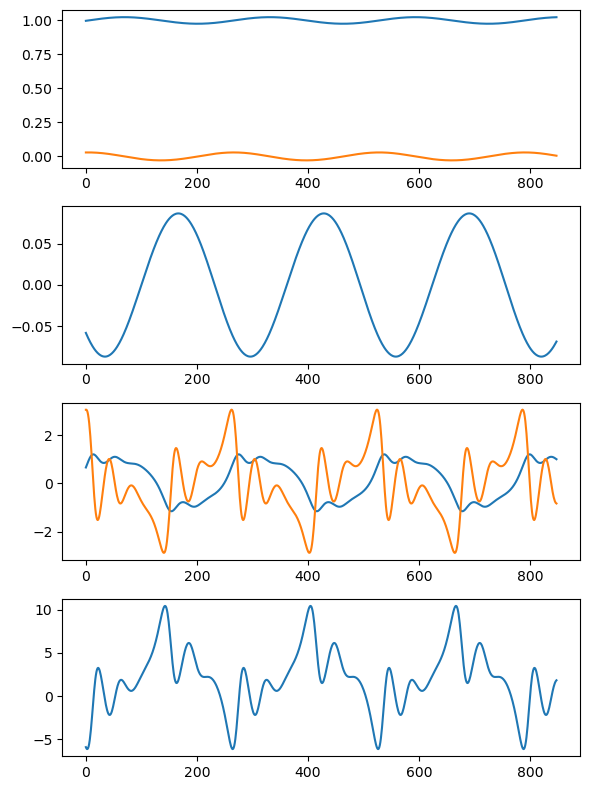

tensor([[[0.9997]]])
tensor([[[1.4332]]])


In [8]:
# --! plot results --!

state, reward, next_state, done = map(torch.cat, zip(*replay_nom.buffer))
state_nom = factory.extract_current_s(state)
action_nom = factory.extract_current_a(state)

state, reward, next_state, done = map(torch.cat, zip(*replay_exc.buffer))
state_exc = factory.extract_current_s(state)
action_exc = factory.extract_current_a(state)

with torch.no_grad():
    plt.figure(figsize=(6,8))

    plt.subplot(4,1,1)
    plt.plot(state_nom[3000:, 0, :2])

    plt.subplot(4,1,2)
    plt.plot(action_nom[3000:, 0, :])

    plt.subplot(4,1,3)
    plt.plot(state_exc[3000:, 0, :2])

    plt.subplot(4,1,4)
    plt.plot(action_exc[3000:, 0, :])

    plt.tight_layout()
    plt.show()

state_nom_norm = torch.mean(torch.linalg.norm(state_nom, dim=-1, keepdim=True), dim=0, keepdim=True)
print(state_nom_norm)

state_exc_norm = torch.mean(torch.linalg.norm(state_exc, dim=-1, keepdim=True), dim=0, keepdim=True)
print(state_exc_norm)

In [9]:
datasaved = True

if datasaved:
    replay_nom.to_file('../../data/dreamer/duffing_nom')
    replay_exc.to_file('../../data/dreamer/duffing_exc')

saving data with a shape torch.Size([1, 3848, 4]) to a file
saving data with a shape torch.Size([1, 3848, 4]) to a file
